In [1]:
# src/eval/harness.py
import json
import numpy as np
from sentence_transformers import SentenceTransformer

MODEL_NAME = "BAAI/bge-small-en-v1.5"   # small, fast, strong for its size -- good default for iterating

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

def embed_texts(texts: list[str], model: SentenceTransformer, batch_size: int = 64) -> np.ndarray:
    """Returns L2-normalized embeddings so dot product == cosine similarity."""
    return model.encode(
        texts, batch_size=batch_size, normalize_embeddings=True,
        show_progress_bar=True, convert_to_numpy=True,
    )

def cosine_top_k(query_vec, chunk_vecs, chunk_ids, k=5):
    sims = chunk_vecs @ query_vec
    top_k_idx = np.argsort(-sims)[:k]
    return [chunk_ids[i] for i in top_k_idx]

def context_precision_at_k(retrieved_ids, gold_ids, k):
    top_k = retrieved_ids[:k]
    return sum(1 for c in top_k if c in gold_ids) / k if top_k else 0.0

def context_recall_at_k(retrieved_ids, gold_ids, k):
    if not gold_ids:
        return None
    top_k = set(retrieved_ids[:k])
    return sum(1 for g in gold_ids if g in top_k) / len(gold_ids)

def evaluate_chunking_strategy(chunks: list[dict], eval_examples: list[dict],
                                 model: SentenceTransformer, k_values=(1, 3, 5, 10)) -> dict:
    """chunks: list of {chunk_id, text, ...}. eval_examples: list of {question, gold_chunk_ids}."""
    chunk_ids = [c["chunk_id"] for c in chunks]
    chunk_texts = [c["text"] for c in chunks]
    chunk_vecs = embed_texts(chunk_texts, model)

    questions = [e["question"] for e in eval_examples]
    query_vecs = embed_texts(questions, model)

    results = {k: {"precision": [], "recall": []} for k in k_values}
    max_k = max(k_values)

    for i, ex in enumerate(eval_examples):
        gold_ids = set(ex["gold_chunk_ids"])
        retrieved = cosine_top_k(query_vecs[i], chunk_vecs, chunk_ids, k=max_k)
        for k in k_values:
            results[k]["precision"].append(context_precision_at_k(retrieved, gold_ids, k))
            r = context_recall_at_k(retrieved, gold_ids, k)
            if r is not None:
                results[k]["recall"].append(r)

    summary = {}
    for k in k_values:
        summary[k] = {
            "precision": float(np.mean(results[k]["precision"])),
            "recall": float(np.mean(results[k]["recall"])),
        }
    return summary

In [3]:
from sentence_transformers import SentenceTransformer
# from src.eval.harness import load_jsonl, evaluate_chunking_strategy
import json

model = SentenceTransformer("BAAI/bge-small-en-v1.5")

chunks = load_jsonl("data/processed/chunks.jsonl")
chunks = [c for c in chunks if not c.get("is_noise", False)]   # exclude junk lines from the index
eval_examples = load_jsonl("data/processed/eval_dataset.jsonl")

print(f"evaluating {len(chunks)} chunks against {len(eval_examples)} questions...")
summary = evaluate_chunking_strategy(chunks, eval_examples, model)

for k, scores in summary.items():
    print(f"k={k:>2}  precision={scores['precision']:.3f}  recall={scores['recall']:.3f}")

with open("data/processed/eval_results_baseline_row_level.json", "w") as f:
    json.dump(summary, f, indent=2)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

evaluating 8532 chunks against 883 questions...


Batches:   0%|          | 0/134 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

k= 1  precision=0.323  recall=0.282
k= 3  precision=0.177  recall=0.421
k= 5  precision=0.123  recall=0.474
k=10  precision=0.075  recall=0.557


In [4]:
# src/eval/harness.py — ADD this to your existing file

def word_overlap_relevance(retrieved_text: str, gold_text: str, threshold: float = 0.6) -> bool:
    gold_words = set(w.lower().strip(".,;:()") for w in gold_text.split())
    retrieved_words = set(w.lower().strip(".,;:()") for w in retrieved_text.split())
    if not gold_words:
        return False
    overlap = len(gold_words & retrieved_words) / len(gold_words)
    return overlap >= threshold

def evaluate_chunking_strategy_generic(chunks: list[dict], eval_examples: list[dict],
                                         chunk_id_to_gold_text: dict, model,
                                         k_values=(1, 3, 5, 10)) -> dict:
    """Works across ANY chunking strategy by using content-overlap relevance
    instead of exact chunk_id matching. chunk_id_to_gold_text maps each
    eval_example's gold_chunk_ids back to their original text content
    (from the row-level chunk store, regardless of what strategy we're testing)."""
    chunk_ids = [c["chunk_id"] for c in chunks]
    chunk_texts = [c["text"] for c in chunks]
    chunk_vecs = embed_texts(chunk_texts, model)

    questions = [e["question"] for e in eval_examples]
    query_vecs = embed_texts(questions, model)

    results = {k: {"precision": [], "recall": []} for k in k_values}
    max_k = max(k_values)

    for i, ex in enumerate(eval_examples):
        gold_texts = [chunk_id_to_gold_text[gid] for gid in ex["gold_chunk_ids"] if gid in chunk_id_to_gold_text]
        if not gold_texts:
            continue
        retrieved_ids = cosine_top_k(query_vecs[i], chunk_vecs, chunk_ids, k=max_k)
        id_to_text = dict(zip(chunk_ids, chunk_texts))

        for k in k_values:
            top_k_texts = [id_to_text[cid] for cid in retrieved_ids[:k]]
            # relevant if ANY retrieved chunk in top-k covers ANY gold fact
            relevant_flags = [
                any(word_overlap_relevance(rt, gt) for gt in gold_texts)
                for rt in top_k_texts
            ]
            precision = sum(relevant_flags) / k
            # recall: did we find coverage for at least one gold fact within top-k
            found_any = any(relevant_flags)
            recall = 1.0 if found_any else 0.0   # simplified: FinQA gold sets are near-always size 1

            results[k]["precision"].append(precision)
            results[k]["recall"].append(recall)

    return {k: {"precision": float(np.mean(v["precision"])), "recall": float(np.mean(v["recall"]))}
            for k, v in results.items()}

In [6]:
def naive_fixed_size_chunks(doc, chunk_size=500, overlap=50):
    """Ignore table/text structure entirely -- just split the flattened full_text
    the way a naive RecursiveCharacterTextSplitter would."""
    # reconstruct a flat text blob the naive way: everything concatenated
    pre = " ".join(item["text"] for item in doc["pre_text"])
    table_flat = " ".join(" ".join(row) for row in doc["table"])
    post = " ".join(item["text"] for item in doc["post_text"])
    full_text = f"{pre} {table_flat} {post}"

    chunks = []
    start = 0
    idx = 0
    while start < len(full_text):
        end = start + chunk_size
        chunk_text = full_text[start:end]
        chunks.append({
            "chunk_type": "fixed_size",
            "row_index": idx,
            "text": chunk_text,
            "chunk_id": f"{doc['doc_id']}::fixed_size::{idx}",
            "doc_id": doc["doc_id"],
            "is_noise": False,
        })
        start += chunk_size - overlap
        idx += 1
    return chunks

with open('data/processed/documents.jsonl') as f:
    documents = [json.loads(l) for l in f]

all_naive_chunks = []
for doc in documents:
    all_naive_chunks.extend(naive_fixed_size_chunks(doc))

print(f"naive fixed-size chunking: {len(all_naive_chunks)} chunks (vs 8,931 for structure-aware)")

naive fixed-size chunking: 2689 chunks (vs 8,931 for structure-aware)


In [ ]:
from sentence_transformers import SentenceTransformer
# from src.eval.harness import load_jsonl, evaluate_chunking_strategy_generic
import json

model = SentenceTransformer("BAAI/bge-small-en-v1.5")

row_level_chunks = load_jsonl("data/processed/chunks.jsonl")
chunk_id_to_gold_text = {c["chunk_id"]: c["text"] for c in row_level_chunks}

naive_chunks = load_jsonl("data/processed/chunks_naive_fixed.jsonl")
eval_examples = load_jsonl("data/processed/eval_dataset.jsonl")

print(f"evaluating naive fixed-size strategy: {len(naive_chunks)} chunks...")
summary = evaluate_chunking_strategy_generic(naive_chunks, eval_examples, chunk_id_to_gold_text, model)

for k, scores in summary.items():
    print(f"k={k:>2}  precision={scores['precision']:.3f}  recall={scores['recall']:.3f}")

with open("data/processed/eval_results_naive_fixed.json", "w") as f:
    json.dump(summary, f, indent=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

evaluating naive fixed-size strategy: 2689 chunks...


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

k= 1  precision=0.516  recall=0.516
k= 3  precision=0.321  recall=0.713
k= 5  precision=0.237  recall=0.765
k=10  precision=0.153  recall=0.815


In [ ]:
def whole_table_chunk(doc):
    """One chunk for the entire table instead of per-row. Text stays line-level
    (unchanged from strategy 1) so we isolate the table-granularity variable."""
    table = doc["table"]
    if not table:
        return []
    header, *rows = table
    lines = [" | ".join(header)]
    for row in rows:
        lines.append(" | ".join(row))
    table_text = "\n".join(lines)
    return [{
        "chunk_type": "whole_table", "row_index": 0, "text": table_text,
        "chunk_id": f"{doc['doc_id']}::whole_table::0", "doc_id": doc["doc_id"], "is_noise": False,
    }]

def text_lines_unchanged(doc):
    combined = doc["pre_text"] + doc["post_text"]
    return [
        {"chunk_type": "text_line", "row_index": i, "text": item["text"],
         "chunk_id": f"{doc['doc_id']}::text_line::{i}", "doc_id": doc["doc_id"], "is_noise": item["is_noise"]}
        for i, item in enumerate(combined)
    ]

strategy3_chunks = []
for doc in documents:
    strategy3_chunks.extend(whole_table_chunk(doc) + text_lines_unchanged(doc))

print(f"Strategy 3 (whole-table): {len(strategy3_chunks)} chunks (vs 8,931 row-level)")
sample = next(c for c in strategy3_chunks if c["chunk_type"] == "whole_table")
print("sample whole-table chunk (first 200 chars):")
print(sample["text"][:200])
print()

with open('data/processed/chunks_whole_table.jsonl', 'w') as f:
    for c in strategy3_chunks:
        f.write(json.dumps(c) + "\n")

def sentence_window_text(doc, window=1):
    """Index each line individually (for matching), but the chunk's TEXT includes
    +/- `window` neighboring lines, giving the retriever/LLM more surrounding context."""
    combined = [item["text"] for item in doc["pre_text"] + doc["post_text"]]
    is_noise_flags = [item["is_noise"] for item in doc["pre_text"] + doc["post_text"]]
    chunks = []
    for i in range(len(combined)):
        start = max(0, i - window)
        end = min(len(combined), i + window + 1)
        window_text = " ".join(combined[start:end])
        chunks.append({
            "chunk_type": "text_window", "row_index": i, "text": window_text,
            "chunk_id": f"{doc['doc_id']}::text_window::{i}", "doc_id": doc["doc_id"],
            "is_noise": is_noise_flags[i],
        })
    return chunks

def table_rows_unchanged(doc):
    table = doc["table"]
    if not table:
        return []
    header, *rows = table
    out = []
    for row_idx, row in enumerate(rows, start=1):
        row_label = row[0]
        if len(row) == len(header):
            facts = [f"{header[j]} is {row[j]}" for j in range(1, len(row)) if row[j].strip()]
            sentence = f"{row_label}: " + "; ".join(facts) + "."
        else:
            values = [v for v in row[1:] if v.strip()]
            sentence = f"{row_label}: values are " + ", ".join(values) + "."
        out.append({"chunk_type": "table_row", "row_index": row_idx, "text": sentence,
                     "chunk_id": f"{doc['doc_id']}::table_row::{row_idx}", "doc_id": doc["doc_id"], "is_noise": False})
    return out

strategy4_chunks = []
for doc in documents:
    strategy4_chunks.extend(table_rows_unchanged(doc) + sentence_window_text(doc, window=1))

print(f"Strategy 4 (sentence-window, w=1): {len(strategy4_chunks)} chunks")
sample_window = next(c for c in strategy4_chunks if c["chunk_type"] == "text_window" and c["row_index"] == 163
                      and c["doc_id"] == "AMAT/2014/page_35.pdf")
print("sample window chunk (center = the North America warehouse line from earlier):")
print(sample_window["text"][:400])

with open('data/processed/chunks_sentence_window.jsonl', 'w') as f:
    for c in strategy4_chunks:
        f.write(json.dumps(c) + "\n")


Strategy 3 (whole-table): 7575 chunks (vs 8,931 row-level)
sample whole-table chunk (first 200 chars):
Company | Payments Volume (billions) | Total Volume (billions) | Total Transactions (billions) | Cards (millions)
Visa Inc.(1) | $2,457 | $3,822 | 50.3 | 1,592
MasterCard | 1,697 | 2,276 | 27.0 | 916


Strategy 4 (sentence-window, w=1): 8931 chunks
sample window chunk (center = the North America warehouse line from earlier):
products in the energy and environmental solutions segment are primarily manufactured in alzenau, germany; treviso, italy; and cheseaux, switzerland. in addition to the above properties, applied also owns and leases offices, plants and/or warehouse locations in 75 locations throughout the world: 16 in europe, 20 in japan, 16 in north america ( principally the united states ), 7 in china, 3 in indi


In [ ]:
from sentence_transformers import SentenceTransformer
import json

model = SentenceTransformer("BAAI/bge-small-en-v1.5")

row_level_chunks = load_jsonl("data/processed/chunks.jsonl")
chunk_id_to_gold_text = {c["chunk_id"]: c["text"] for c in row_level_chunks}

strategy3_chunks = load_jsonl("data/processed/chunks_whole_table.jsonl")
eval_examples = load_jsonl("data/processed/eval_dataset.jsonl")

print(f"evaluating whole-table strategy: {len(strategy3_chunks)} chunks...")
summary = evaluate_chunking_strategy_generic(strategy3_chunks, eval_examples, chunk_id_to_gold_text, model)
for k, s in summary.items():
    print(f"k={k:>2}  precision={s['precision']:.3f}  recall={s['recall']:.3f}")

with open("data/processed/eval_results_whole_table.json", "w") as f:
    json.dump(summary, f, indent=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

evaluating whole-table strategy: 7575 chunks...


Batches:   0%|          | 0/119 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

k= 1  precision=0.466  recall=0.466
k= 3  precision=0.280  recall=0.630
k= 5  precision=0.205  recall=0.709
k=10  precision=0.129  recall=0.798


In [ ]:
from sentence_transformers import SentenceTransformer
import json

model = SentenceTransformer("BAAI/bge-small-en-v1.5")

row_level_chunks = load_jsonl("data/processed/chunks.jsonl")
chunk_id_to_gold_text = {c["chunk_id"]: c["text"] for c in row_level_chunks}

strategy4_chunks = load_jsonl("data/processed/chunks_sentence_window.jsonl")
eval_examples = load_jsonl("data/processed/eval_dataset.jsonl")

print(f"evaluating sentence-window strategy: {len(strategy4_chunks)} chunks...")
summary = evaluate_chunking_strategy_generic(strategy4_chunks, eval_examples, chunk_id_to_gold_text, model)
for k, s in summary.items():
    print(f"k={k:>2}  precision={s['precision']:.3f}  recall={s['recall']:.3f}")

with open("data/processed/eval_results_sentence_window.json", "w") as f:
    json.dump(summary, f, indent=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

evaluating sentence-window strategy: 8931 chunks...


Batches:   0%|          | 0/140 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

k= 1  precision=0.479  recall=0.479
k= 3  precision=0.399  recall=0.597
k= 5  precision=0.328  recall=0.652
k=10  precision=0.237  recall=0.722


Strategy                       P@5      R@5     P@10     R@10
Row-level (baseline)         0.123    0.474    0.075    0.557
Naive fixed-size             0.237    0.765    0.153    0.815
Whole-table                  0.205    0.709    0.129    0.798
Sentence-window              0.328    0.652    0.237    0.722


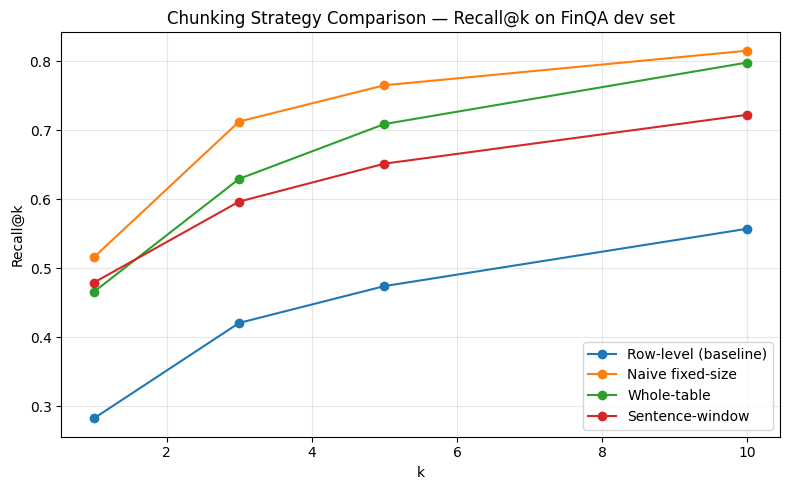

In [13]:
import json
import matplotlib.pyplot as plt

strategies = {
    "Row-level (baseline)": "data/processed/eval_results_baseline_row_level.json",
    "Naive fixed-size": "data/processed/eval_results_naive_fixed.json",
    "Whole-table": "data/processed/eval_results_whole_table.json",
    "Sentence-window": "data/processed/eval_results_sentence_window.json",
}

all_results = {}
for name, path in strategies.items():
    with open(path) as f:
        all_results[name] = {int(k): v for k, v in json.load(f).items()}

# print comparison table at k=5
print(f"{'Strategy':<25} {'P@5':>8} {'R@5':>8} {'P@10':>8} {'R@10':>8}")
for name, res in all_results.items():
    print(f"{name:<25} {res[5]['precision']:>8.3f} {res[5]['recall']:>8.3f} "
          f"{res[10]['precision']:>8.3f} {res[10]['recall']:>8.3f}")

# plot recall@k curves for all strategies
fig, ax = plt.subplots(figsize=(8, 5))
k_values = sorted(next(iter(all_results.values())).keys())
for name, res in all_results.items():
    recalls = [res[k]["recall"] for k in k_values]
    ax.plot(k_values, recalls, marker="o", label=name)
ax.set_xlabel("k")
ax.set_ylabel("Recall@k")
ax.set_title("Chunking Strategy Comparison — Recall@k on FinQA dev set")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/chunking_comparison.png", dpi=120)
plt.show()